# Integrated Machine‑Learning Pipeline for Diabetes Risk Prediction

Diabetes is a chronic disease that affected 830 million people around the world as 
at 2022. This project aims to briefly explore a diabetes data set and create machine learning models that can predict the presence or absence of diabetes based on the features in the data.

In [5]:
# Performing necessary imports
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
# Downloading the data set from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Hp\.cache\kagglehub\datasets\iammustafatz\diabetes-prediction-dataset\versions\1


In [7]:
# Loading the data into a pandas DataFrame
data = pd.read_csv(r'C:/Users/Hp/.cache/kagglehub/datasets/iammustafatz/diabetes-prediction-dataset/versions/1/diabetes_prediction_dataset.csv')

In [8]:
# Viewing the first 5 rows of the data 
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [9]:
# Calling .info() on the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [10]:
# Calling .describe() on the data to get summary statistics 
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Since there are no missing values and the data types are consistent, we can now
move onto Exploratory Data Analysis

### Exploratory Data Analysis(EDA)

In [13]:
# Printing a list of the columns in the data 
print(data.columns)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


<Axes: title={'center': 'Distribution of Diabetes by Gender'}, xlabel='gender', ylabel='count'>

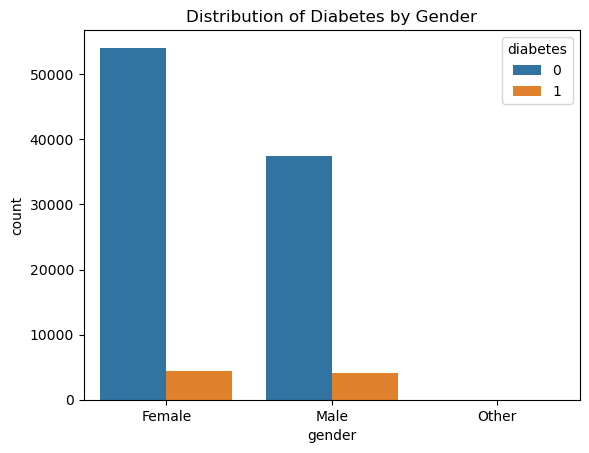

In [14]:
# Using countplot to see diabtes distributed by gender
plt.title('Distribution of Diabetes by Gender')
sns.countplot(data=data, x='gender', hue='diabetes')

The data set seems to have a higher proportion of **Females** to **Males** with patients whose
gender was recorded as **Other** being the minority

In [16]:
# Using value_counts to see distribution of unique values in the gender column
data['gender'].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

<Axes: title={'center': 'Distrubution of Diabetes across Patients with Hypertension'}, xlabel='hypertension', ylabel='count'>

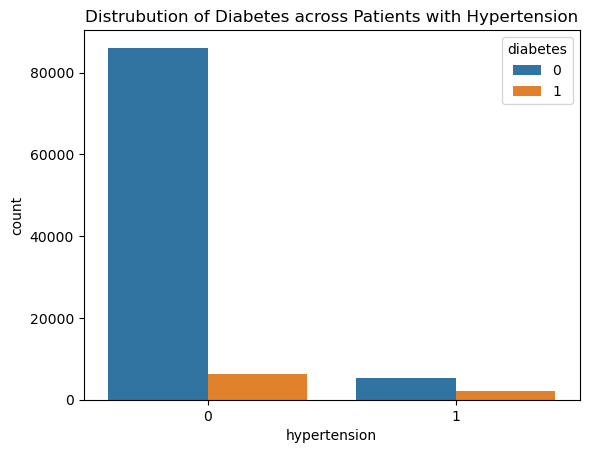

In [17]:
# Finding distribution of diabetes among hypertension 
plt.title('Distrubution of Diabetes across Patients with Hypertension')
sns.countplot(data=data, x='hypertension', hue='diabetes')

From the above plot it can be seen that in this data people without hypertension
are more likely to also not have diabetes. This makes sense as hypertension is a risk
factor for diabetes and so the lack of hypertension corresponds with not having diabetes

<Axes: title={'center': 'Distribution of Diabetes across Patients with Heart Disease'}, xlabel='heart_disease', ylabel='count'>

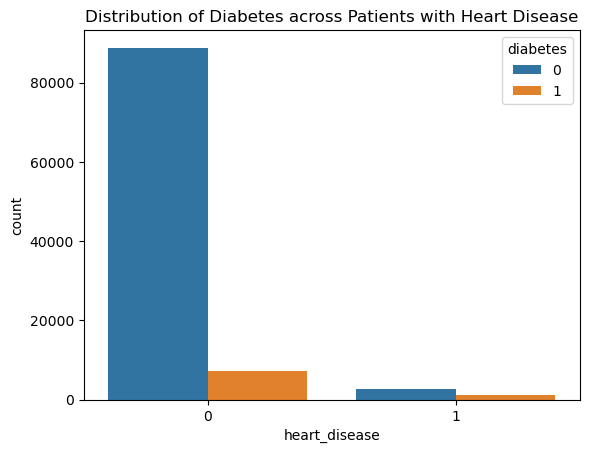

In [19]:
# Finding distribution of diabetes across heart disease
plt.title('Distribution of Diabetes across Patients with Heart Disease')
sns.countplot(data=data, x='heart_disease', hue='diabetes')

From the above plot it can be seen that from the data, patients without heart disease
are more likely to also not have diabetes. This makes sense as heart disease is a risk factor 
for diabetes and so a lack of heart disease corresponds to not having diabetes

<Axes: title={'center': 'Distribution of Diabetes across Patients with Smoking History'}, xlabel='smoking_history', ylabel='count'>

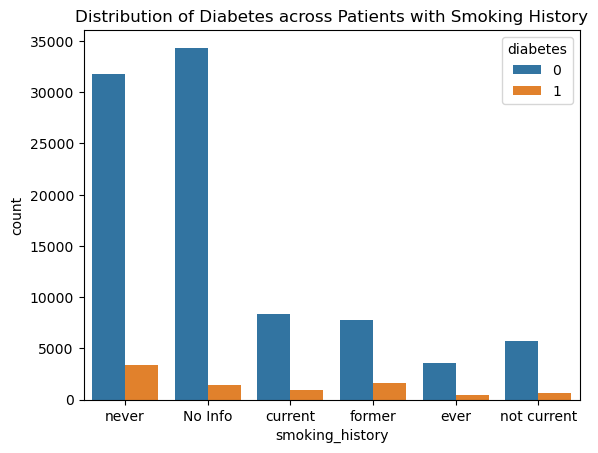

In [21]:
# Finding distribution of diabetes across smoking 
plt.title('Distribution of Diabetes across Patients with Smoking History')
sns.countplot(data=data, x='smoking_history', hue='diabetes')

From the plot above it can be seen that patients who never smoked are more likely to not have
diabetes. Also visually it can be seen that about 25% of patients who formerly smoked had
diabetes. Also from a visual perspective about 15% of patients who currently smoke had diabetes.
This plot underscores the fact that smoking is indeed a risk factor for diabetes

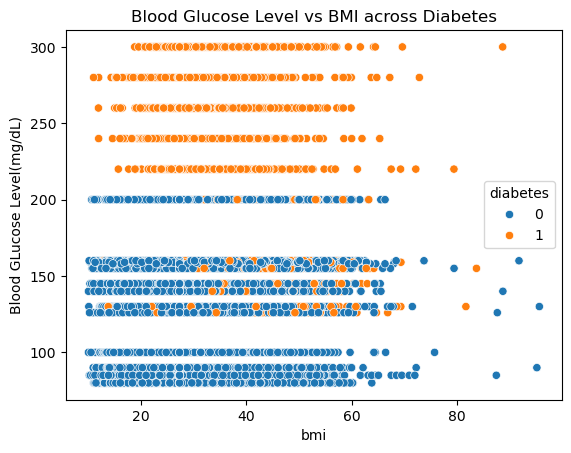

In [23]:
# Plotting Blood glucose level against BMI with diabetes as hue
plt.title('Blood Glucose Level vs BMI across Diabetes')
plt.ylabel('Blood GLucose Level(mg/dL)')
sns.scatterplot(data=data , x='bmi', y='blood_glucose_level', hue='diabetes')
plt.show()

From the scatterplot above it can be seen that generally, patients with high blood glucose levels and a higher BMI are more likely to have diabetes. This makes sense as a **higher BMI** is a risk 
factor for diabetes and **consistently elevated blood glucose levels** are indicative of diabetes.\
For more context the normal range for fasting blood glucose levels according to the World Health
Organization(WHO) is between **70 mg/dL and 100 mg/dL**. Anything above 100 mg/dL is elevated.\
Also according to the WHO the normal range for BMI is between **18.5 and 24.9**. Anything above 24.9 is either overweight or obese

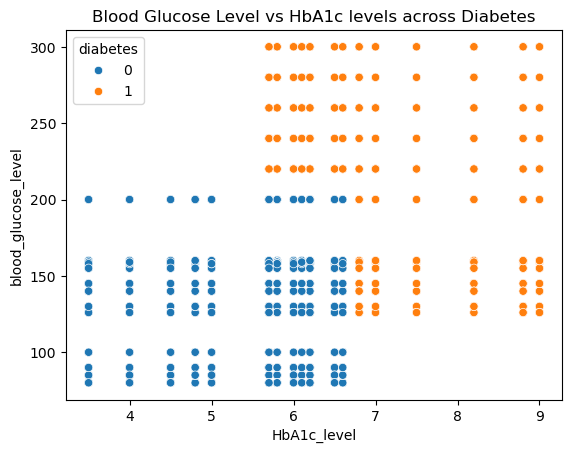

In [25]:
# Plotting Blood glucose levels against HbA1c levels with diabetes as hue
plt.title('Blood Glucose Level vs HbA1c levels across Diabetes')
sns.scatterplot(data=data, x='HbA1c_level', y='blood_glucose_level',
               hue='diabetes')
plt.show()

HbA1c(Haemoglobin A1c) or glycated haemoglobin is a test done to measure the average
amount of glucose in blood over the past 2 to 3 months by assessing how much glucose is attached 
to red blood cells. The results of this test, usually measure in mmol/mol or a percentage is 
used to diagnose a patient with diabetes.\
Due to the changing nature of blood glucose levels, HbA1c is a **more reliable and accurate method** for diagnosing diabetes as it measures the average glucose levels in the blood over a period rather than at an instant as in the case of blood glucose level measurement.\
According to the WHO the normal range for HbA1c for people without diabetes is **less than 5.7%**.
HbA1c levels that are **6.5% and above** are likely indicative of diabetes.\
The scatterplot above highlights this as nearly all patients with HbA1c above 6.5% have diabetes and those patients with HbA1c below 5.7% do not have diabetes

We have now explored the data and uncovered a number of insights. Let us now dive into
the Machine Learning aspect of our project

## Machine Learning

Before we begin developing machine learning models we will have to do some feature 
engineering as some columns cannot be used to train our machine learning models

In [30]:
# Create a boolean mask for categorical columns
categorical_mask = (data.dtypes == object)

# Get list of categorical column names
categorical_columns = data.columns[categorical_mask].tolist()

# Print the head of the categorical columns
print(data[categorical_columns].head())

   gender smoking_history
0  Female           never
1  Female         No Info
2    Male           never
3  Female         current
4    Male         current


In [31]:
# Performing one hot encoding on the smoking_history and gender columns 
data = pd.get_dummies(data=data, columns=['smoking_history', 'gender'], dtype=int, drop_first=True)
# Viewing first 5 rows of the new data
data.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Male,gender_Other
0,80.0,0,1,25.19,6.6,140,0,0,0,0,1,0,0,0
1,54.0,0,0,27.32,6.6,80,0,0,0,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,0,0,1,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,1,0,0,0,0,1,0


Now that we have One Hot Encoded both the smoking_history gender columns we can now move on 
to the model development. 

### Logistic Regression

Since the target column of this diabetes data set is a categorical column, this machine 
learning problem is a supervised classification problem. To start our machine learning model
development we will use a **Logistic Regression model** which is good for basic classification
tasks. Depending on the model's performance, we will decide to develop more powerful models
to obtain better results

In [35]:
# Separating data into features and target
X = data.drop('diabetes', axis=1)#features
y = data['diabetes']#target

In [36]:
# Doing necessary imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

In [37]:
# Setting a seed for reproducibility
SEED=101

In [38]:
# Splitting features and target into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

In [39]:
# Instantiating StandardScaler as scaler 
scaler = StandardScaler()

In [40]:
# Instantiating LogisticRegression as logmodel 
logmodel = LogisticRegression()

In [41]:
# Creating a pipeline object consisting of StandardScaler and LogisticRegression
pipeline_log = make_pipeline(scaler, logmodel)

In [42]:
# Fitting the pipeline object to the training data
pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression())])

In [43]:
# Predicting off the test data
y_pred = pipeline_log.predict(X_test)
# Predicting probabilities to be used in roc_auc 
y_pred_proba = pipeline_log.predict_proba(X_test)[:,1]

In [44]:
# Importing evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [45]:
# Printing the confusion matrix
print('For the Logistic Regression Model:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the Logistic Regression Model:

[[27243   232]
 [  946  1579]]


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27475
           1       0.87      0.63      0.73      2525

    accuracy                           0.96     30000
   macro avg       0.92      0.81      0.85     30000
weighted avg       0.96      0.96      0.96     30000



In [46]:
# Printing the roc_auc_score
print(f'For the Logistic Regression Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the Logistic Regression Model:
ROC_AUC_Score: 0.96


In [47]:
# Finding distribution of diabetes in the data
data['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

This data set is an imbalanced data set where 91.5% of the data points are classified as  
not having diabetes. This means that a model that always predicts no diabetes will have 
a high accuracy of 91.5% but it would be **wrongly predicting diabetes**.\
And so accuracy will not be used to evaluate the performance of the model. What will be used is **recall**. This is because recall as a metric evaluates the reduction of false negatives which in this case is a patient who has diabetes being **wrongly classified** as not having diabetes. This is more important as it is more costly to misdiagnose a diabetic patient as healthy rather than diagnose a healthy patient as diabetic.\
And so recall, as well as the ROC AUC score(The area under the Receiver Operating Characteristic curve) which indicates the ability of a model to distinguish between classes will be used to evaluate our models

Looking at the Logistic Regression model in terms of recall, it did not perform too badly. Its
ROC AUC score was also good. However there may be room for improvement and so let's develop 
more powerful models to see whether we can get better performance

### Decision Tree Model

Let's now see whether a Decision Tree model can outperform the Logistic Regression model

In [52]:
# Importing DecisionTreeClassifier from scikit-learn library
from sklearn.tree import DecisionTreeClassifier

In [53]:
# Instantiating DecisionTreeClassifier as dtree 
dtree = DecisionTreeClassifier(max_depth=3, random_state=SEED, class_weight='balanced')

In [54]:
# Creating a pipeline object consisting of StandardScaler and DecisionTreeClassifier 
pipeline_dt = make_pipeline(scaler, dtree)

In [55]:
# Fitting the pipeline object to the training data 
pipeline_dt.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                                        random_state=101))])

In [56]:
# Predicting off test data
y_pred = pipeline_dt.predict(X_test)
# Predicting probabilities to be used in roc_auc_score
y_pred_proba = pipeline_dt.predict_proba(X_test)[:,1]

In [57]:
# Printing the confusion matrix
print('For the Decision Tree Model:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the Decision Tree Model:

[[27475     0]
 [  850  1675]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27475
           1       1.00      0.66      0.80      2525

    accuracy                           0.97     30000
   macro avg       0.98      0.83      0.89     30000
weighted avg       0.97      0.97      0.97     30000



In [58]:
# Printing the roc_auc_score
print(f'For the Decision Tree Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the Decision Tree Model:
ROC_AUC_Score: 0.90


In terms of recall, the DecisionTreeClassifier did slightly better than the Logistic
Regression model. However when it comes to the roc auc score the Logistic Regression model still
outperformed the DecisionTreeClassfier.\
Let's tune the hyperparameters of our DecisionTreeClassifier and see whether we can get better 
results after tuning.

In [60]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [61]:
# Define params_dt
params_dt = {'decisiontreeclassifier__max_depth': [2,3,4,5],
            'decisiontreeclassifier__min_samples_leaf': [0.12,0.14,0.16,0.18]}

# Instantiate grid_dt
grid_dt = GridSearchCV(estimator=pipeline_dt,
                       param_grid=params_dt,
                       scoring='roc_auc',
                       cv=5, verbose=1,
                       n_jobs=-1)

In [62]:
# Fitting the GridSearchCV object to the training data
grid_dt.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('decisiontreeclassifier',
                                        DecisionTreeClassifier(class_weight='balanced',
                                                               max_depth=3,
                                                               random_state=101))]),
             n_jobs=-1,
             param_grid={'decisiontreeclassifier__max_depth': [2, 3, 4, 5],
                         'decisiontreeclassifier__min_samples_leaf': [0.12,
                                                                      0.14,
                                                                      0.16,
                                                                      0.18]},
             scoring='roc_auc', verbose=1)

In [63]:
# Assigning the best estimator to best_pipeline_dt
best_pipeline_dt = grid_dt.best_estimator_

In [64]:
# Predicting off test data
y_pred = best_pipeline_dt.predict(X_test)
# Predicting probabilities to be used in roc_auc_score 
y_pred_proba = best_pipeline_dt.predict_proba(X_test)[:,1]

In [65]:
y_pred

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [66]:
# Printing the confusion matrix
print('For the Tuned Decision Tree Model:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the Tuned Decision Tree Model:

[[22931  4544]
 [  580  1945]]


              precision    recall  f1-score   support

           0       0.98      0.83      0.90     27475
           1       0.30      0.77      0.43      2525

    accuracy                           0.83     30000
   macro avg       0.64      0.80      0.67     30000
weighted avg       0.92      0.83      0.86     30000



In [67]:
# Printing the roc_auc_score
print(f'For the Tuned Decision Tree Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the Tuned Decision Tree Model:
ROC_AUC_Score: 0.87


It seeems the hyperparamter tuning has rather worsened the performance. Let's move on to a new model and see whether we can
improve on the performance

### KNN model

We will now train a KNN(K Nearest Neighbours) model and see whether we will get better 
performance than our original DecisionTreeClassifier

In [71]:
# Importing neccessary libraries
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.metrics import recall_score

In [72]:
# Importing joblib to increase processing speed
from joblib import Parallel, delayed

# Scaling the data using the scaler object
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to calculate error for a given k
def compute_error(k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    return np.mean(pred != y_test)

# Parallel processing across all values of k
error_rate = Parallel(n_jobs=-1)(
    delayed(compute_error)(k) for k in range(1, 40)
)

In [73]:
# Setting the style to darkgrid use seaborns set_style method
sns.set_style('darkgrid')

Text(0, 0.5, 'Error Rate')

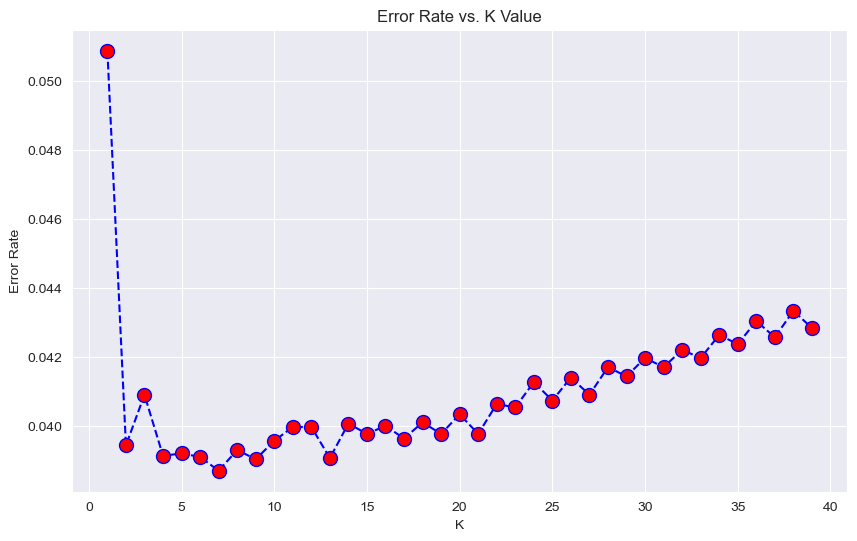

In [74]:
# Creating a plot of error rate against the number of neighbours(k value)
plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

A KNN with `n_neighbors = 7` gave us the lowest error so we will use this to develop our 
model.\
The method used here is commonly know as the elbow method

In [76]:
# Instantiating a KNeighborsClassifier as knn
knn = KNeighborsClassifier(n_neighbors=7)

In [77]:
# Creating a pipeline object consisting of StandardScaler and KNeighborsClassifier
pipeline_knn = make_pipeline(scaler, knn)

In [78]:
# Fitting the pipeline object to the training data
pipeline_knn.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=7))])

In [79]:
# Predicting off the test data
y_pred = pipeline_knn.predict(X_test)
# Predicting probabilities to be used in roc_auc_score
y_pred_proba = pipeline_knn.predict_proba(X_test)[:,1]

In [80]:
# Printing the confusion matrix
print('For the KNN Model:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the KNN Model:

[[27346   129]
 [ 1032  1493]]


              precision    recall  f1-score   support

           0       0.96      1.00      0.98     27475
           1       0.92      0.59      0.72      2525

    accuracy                           0.96     30000
   macro avg       0.94      0.79      0.85     30000
weighted avg       0.96      0.96      0.96     30000



In [81]:
# Printing the roc_auc_score
print(f'For the KNN Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the KNN Model:
ROC_AUC_Score: 0.92


The KNN model did not perform as well as the original Decision Tree Model. It didn't even 
perform as well as the Logistic Regression model. However we can possibly improve by 
using another kind of machine learning model known as **ensemble model** and see whether we can get better results

### Voting Classifier Model

A Voting Classifier is an ensemble model that combines a number of different models into one model that has better
performance than each of the individual models. Let's see whether this model will give us the better results that we're 
looking for

In [85]:
from sklearn.ensemble import RandomForestClassifier
# Instantiate LogisticRegression as lr
lr = LogisticRegression(random_state=SEED)

# Instantiate KNeighborsClassifer 
knn = KNeighborsClassifier(n_neighbors=7)

# Instantiate DecisionTreeClassifier as dt
dt = DecisionTreeClassifier(max_depth=3, random_state=SEED)

#Instantiate RandomForestsClassifier as rfc
rfc = RandomForestClassifier(n_estimators=50, random_state=SEED)

# Define the list classifiers
classifiers = [('Logistic Regression', lr), ('K Nearest Neighbours', knn), ('Decision Tree Classifier', dt), 
              ('Random Forests Classifier', rfc)]

In [86]:
# Importing VotingClassifier from scikit-learn library
from sklearn.ensemble import VotingClassifier

In [87]:
# Instantiating VotingClassifer as vc
vc = VotingClassifier(estimators=classifiers, voting='soft')

In [88]:
# Creating a pipeline object consisting of StandardScaler and VotingClassifier
pipeline_vc = make_pipeline(scaler, vc)

In [89]:
# Fitting the pipeline object to the training data 
pipeline_vc.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('votingclassifier',
                 VotingClassifier(estimators=[('Logistic Regression',
                                               LogisticRegression(random_state=101)),
                                              ('K Nearest Neighbours',
                                               KNeighborsClassifier(n_neighbors=7)),
                                              ('Decision Tree Classifier',
                                               DecisionTreeClassifier(max_depth=3,
                                                                      random_state=101)),
                                              ('Random Forests Classifier',
                                               RandomForestClassifier(n_estimators=50,
                                                                      random_state=101))],
                                  voting='soft'))])

In [90]:
# Predicting off the test data 
y_pred = pipeline_vc.predict(X_test) 
# Predicting probabilities to be used in roc_auc_score 
y_pred_proba = pipeline_vc.predict_proba(X_test)[:,1]

In [91]:
# Printing the confusion matrix
print('For the Voting Classifier Model:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the Voting Classifier Model:

[[27466     9]
 [  846  1679]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27475
           1       0.99      0.66      0.80      2525

    accuracy                           0.97     30000
   macro avg       0.98      0.83      0.89     30000
weighted avg       0.97      0.97      0.97     30000



In [92]:
# Printing the roc_auc_score
print(f'For the Voting Classifier Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the Voting Classifier Model:
ROC_AUC_Score: 0.97


The Voting Classifier model used combined four sub_estimators and gave a classification report similar to the original Decision 
Tree Model. However it did better in the ROC AUC score indicating that it is better at distinguishing between classes. Let's 
continue and develop more models to see whether we can get better results.

### XGBoost Model

Extreme gradient boosting with XGBoost models is a powerful machine learning technique. Let's see whether XGBoost will give 
better results than our Voting Classifier

In [96]:
# Importing the xgboost library
import xgboost as xgb

In [97]:
# Instantiating XGBClassifier as xg_cl 
xg_cl = xgb.XGBClassifier(objective='binary:logistic', n_estimators=10, seed=SEED)

In [98]:
# Creating a pipeline object consisting of Standard Scaler and XGBClassifier 
pipeline_xgb = make_pipeline(scaler, xg_cl)

In [99]:
# Fitting the pipeline object to the training data 
pipeline_xgb.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=10, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [100]:
# Predicting off the test data 
y_pred = pipeline_xgb.predict(X_test)
# Predicting probabilities to be used for roc_auc 
y_pred_proba = pipeline_xgb.predict_proba(X_test)[:,1]

In [101]:
# Printing the confusion matrix
print('For the XGBoost Model:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the XGBoost Model:

[[27470     5]
 [  846  1679]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27475
           1       1.00      0.66      0.80      2525

    accuracy                           0.97     30000
   macro avg       0.98      0.83      0.89     30000
weighted avg       0.97      0.97      0.97     30000



In [102]:
# Printing the roc_auc_score
print(f'For the XGBoost Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the XGBoost Model:
ROC_AUC_Score: 0.98


From the results it can be seen that the XGBoost Classifer outperformed the Voting Classifier which consisted of four 
sub_estimators. This underscores the powerful nature behind the XGBoost model. Let's see whether we can tune the XGBoost model 
to get even better results

In [104]:
# Importing RandomizedSearchCV for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
# Creating a parameter grid
gbm_param_grid = {
    'xgbclassifier__learning_rate': np.arange(0.05, 1, 0.05),
    'xgbclassifier__max_depth': np.arange(3, 10, 1), 
    'xgbclassifier__n_estimators': np.arange(10, 200, 10)
}
# Instantiating a RandomizedSearchCV object as random_xgb 
random_xgb = RandomizedSearchCV(estimator=pipeline_xgb, cv=5, n_iter=12, scoring='roc_auc', verbose=2,
                               param_distributions=gbm_param_grid)

In [105]:
# Fitting the RandomizedSearchCV object to the training data
random_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END xgbclassifier__learning_rate=0.8, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=160; total time=   1.6s
[CV] END xgbclassifier__learning_rate=0.8, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=160; total time=   0.9s
[CV] END xgbclassifier__learning_rate=0.8, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=160; total time=   1.0s
[CV] END xgbclassifier__learning_rate=0.8, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=160; total time=   0.6s
[CV] END xgbclassifier__learning_rate=0.8, xgbclassifier__max_depth=4, xgbclassifier__n_estimators=160; total time=   1.2s
[CV] END xgbclassifier__learning_rate=0.7000000000000001, xgbclassifier__max_depth=6, xgbclassifier__n_estimators=70; total time=   0.6s
[CV] END xgbclassifier__learning_rate=0.7000000000000001, xgbclassifier__max_depth=6, xgbclassifier__n_estimators=70; total time=   0.6s
[CV] END xgbclassifier__learning_rate=0.7000000000

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('standardscaler',
                                              StandardScaler()),
                                             ('xgbclassifier',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric=None,
                                                            feature_types=None,
                                                            feature_weights=None,
                                                            g...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=12,
                   param_distributions={'xgbclassifier__learning_rate': array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95]),
                                        'xgbclassifier__max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                        'xgbclassifier__n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190])},
                   scoring='roc_auc', verbose=2)

In [106]:
# Printing the best score
print(round(random_xgb.best_score_, 2))

0.98


In [107]:
# Assigning the best estimator to best_pipeline_xgb
best_pipeline_xgb = random_xgb.best_estimator_

In [108]:
# Predicting off the test data
y_pred = best_pipeline_xgb.predict(X_test) 
# Predicting probabilities to be used in roc_auc_score 
y_pred_proba = best_pipeline_xgb.predict_proba(X_test)[:,1]

In [109]:
# Printing the confusion matrix
print('For the Tuned XGBoost Model:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the Tuned XGBoost Model:

[[27419    56]
 [  805  1720]]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27475
           1       0.97      0.68      0.80      2525

    accuracy                           0.97     30000
   macro avg       0.97      0.84      0.89     30000
weighted avg       0.97      0.97      0.97     30000



In [110]:
# Printing the roc_auc_score
print(f'For the Tuned XGBoost Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the Tuned XGBoost Model:
ROC_AUC_Score: 0.98


By tuning hyperparameters we have managed to improve the XGBoost model's performance slightly with respect to recall.\
This seems satisfactory with respect to machine learning. Now let us move on to a new aspect, Deep Learning and see what 
performance Deep Learning Models will give us with this data

## Deep Learning

### ANNs with Tensorflow

We will now develop an ANN(Artificial Neural Network) using the Keras api of the Tensorflow library. Let's see 
whether a Deep Learning model will outperform the XGBoost model

In [114]:
# Importing the necessary libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [115]:
# Building the deep learning model
# Instantiate a sequential model 
model = Sequential()
# Adding an Input Layer of 13 neurons
model.add(Input(shape=(13,)))

# Adding a hidden layer of 64 neurons.
model.add(Dense(9, activation='relu'))
# Adding a BatchNormalization layer
model.add(BatchNormalization())

# Adding a final layer with 1 neuron and sigmoid activation function
model.add(Dense(1, activation='sigmoid'))

# Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy',
             metrics=['accuracy'])

# Viewing the summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 9)                   │             126 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 9)                   │              36 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              10 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 172 (688.00 B)

 Trainable params: 154 (616.00 B)

 Non-trainable params: 18 (72.00 B)

In [116]:
# Creating an EarlyStopping callback to stop training early 
earlystopping = EarlyStopping(monitor='val_loss', mode='min',
                              verbose=1,patience=5, restore_best_weights=True)

In [117]:
# Adding a print statement
print('Training started...., this can take a while:')

# Fitting the model to the training data and saving its history 
h_callback = model.fit(X_train, y_train, epochs=1000,
                      validation_data=(X_test,y_test), batch_size=128,
                      callbacks=[earlystopping])

Training started...., this can take a while:
Epoch 1/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8096 - loss: 0.4505 - val_accuracy: 0.9237 - val_loss: 0.1884
Epoch 2/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9563 - loss: 0.1417 - val_accuracy: 0.9532 - val_loss: 0.1278
Epoch 3/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9568 - loss: 0.1214 - val_accuracy: 0.9183 - val_loss: 0.1880
Epoch 4/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9573 - loss: 0.1189 - val_accuracy: 0.9600 - val_loss: 0.1157
Epoch 5/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9588 - loss: 0.1172 - val_accuracy: 0.9583 - val_loss: 0.1211
Epoch 6/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9584 - loss: 0.1154 - val_accuracy: 0.9587 - val_loss: 0.1157
Epoch 7/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9576 - loss: 0.1182 - val_accuracy: 0.9578 - val_loss: 0.1173
Epoch 8/1000
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [118]:
# Finding the accuracy of the model
accuracy = model.evaluate(X_test, y_test)[1]
print(f'Accuracy: {(accuracy*100):.2f}%')

938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9593 - loss: 0.1153
Accuracy: 96.03%


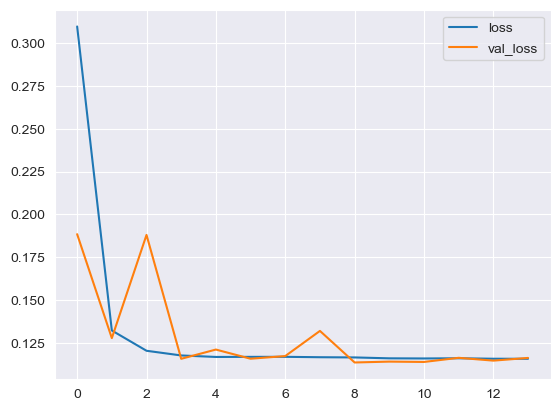

In [119]:
# Creating a pandas DataFrame of model history
model_history = pd.DataFrame(h_callback.history)

# Plotting loss and val_loss
plt.plot(model_history['loss'], label='loss')
plt.plot(model_history['val_loss'], label='val_loss')
plt.legend() 
plt.show()

**loss** refers to loss incurred by the ANN on the training data and **val_loss** refers to loss incurred by the ANN on the 
validation_data. The plot above shows the **loss** and **val_loss** per epoch of the model training

In [120]:
# Predicting off of the test dataw
y_pred = (model.predict(X_test) > 0.5).astype("int32") 
# Predicting probabilities to be used in roc_auc_score
y_pred_proba = model.predict(X_test)

938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [121]:
# Printing the confusion matrix
print('For the ANN:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the ANN:

[[27276   199]
 [  991  1534]]


              precision    recall  f1-score   support

           0       0.96      0.99      0.98     27475
           1       0.89      0.61      0.72      2525

    accuracy                           0.96     30000
   macro avg       0.93      0.80      0.85     30000
weighted avg       0.96      0.96      0.96     30000



In [122]:
# Printing the roc_auc_score
print(f'For the ANN Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the ANN Model:
ROC_AUC_Score: 0.96


The performance of the ANN was good however it was not better than the XGBoost model. Let's see whether we can get better 
performance by tuning its hyperparameters. This time we will be using the RandomizedSearchCV module of the scikit-learn library

In [123]:
# Importing the Adam optimizer from keras
from tensorflow.keras.optimizers import Adam

In [124]:
# Creating a function to build ANN models
# Creates a model given an activation and learning rate
def create_model(learning_rate, activation):
    
    # Create an Adam optimizer with the given learning rate
    opt = Adam(learning_rate = learning_rate)
    
    # Create your binary classification model  
    model = Sequential()
    model.add(Input(shape=(13,)))
    model.add(Dense(9, activation = activation))
    model.add(BatchNormalization())
    model.add(Dense(1, activation = 'sigmoid'))
    
    # Compile your model with your optimizer, loss, and metrics
    model.compile(optimizer = opt, loss='binary_crossentropy', metrics = ['accuracy'])
    return model

In [125]:
from sklearn.model_selection import KFold

In [126]:
# Import KerasClassifier from tensorflow.keras scikit learn wrappers
from scikeras.wrappers import KerasClassifier

# Define the parameters to try out
params = {'model__activation': ['relu', 'tanh'], 'batch_size': [32, 128, 256], 
          'epochs': [50, 100, 200], 'model__learning_rate': [0.1, 0.01, 0.001]}

# Create a KerasClassifier
keras_cl = KerasClassifier(model = create_model, activation=params['model__activation'], batch_size=params['batch_size'],
                          epochs=params['epochs'], learning_rate=params['model__learning_rate'])

# Create a randomize search cv object passing in the parameters to try
random_search = RandomizedSearchCV(keras_cl, param_distributions = params, n_iter=12, n_jobs=-1, verbose=2, cv = KFold(3))

In [127]:
# Importing time module
import time

In [218]:
# Setting the initial time t0
t0 = time.time()
# Fitting the RandomizedSearchCV object
random_search.fit(X_train, y_train, validation_data=(X_test,y_test), callbacks=[earlystopping])
# Printing the training time
print("Training time:", time.time()-t0)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Epoch 1/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.6871 - loss: 0.6166 - val_accuracy: 0.9467 - val_loss: 0.2813
Epoch 2/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9463 - loss: 0.2257 - val_accuracy: 0.9268 - val_loss: 0.1780
Epoch 3/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9559 - loss: 0.1469 - val_accuracy: 0.9312 - val_loss: 0.1685
Epoch 4/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9573 - loss: 0.1294 - val_accuracy: 0.9579 - val_loss: 0.1219
Epoch 5/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9568 - loss: 0.1222 - val_accuracy: 0.9590 - val_loss: 0.1170
Epoch 6/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9584 - loss: 0.1180 - val_accuracy: 0.9434 - val_loss: 0.1424
Epoch 7/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9569 - loss: 0.1189 - val_accuracy: 0.9596 - val_loss: 0.1164
Epoch 8/200
274/274 ━━━━━━━━━━━━━━

In [268]:
# Printing the best score
print(random_search.best_score_)

0.9612428599841402


In [224]:
# Printing the best parameters
print(random_search.best_params_)

{'model__learning_rate': 0.001, 'model__activation': 'relu', 'epochs': 200, 'batch_size': 256}


In [226]:
# Assigning the best estimator from random_search to best_model
best_model = random_search.best_estimator_

In [244]:
# Finding the accuracy of the model
accuracy = best_model.score(X_test, y_test)
print(f'Accuracy: {(accuracy*100):.2f}%')

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy: 95.01%


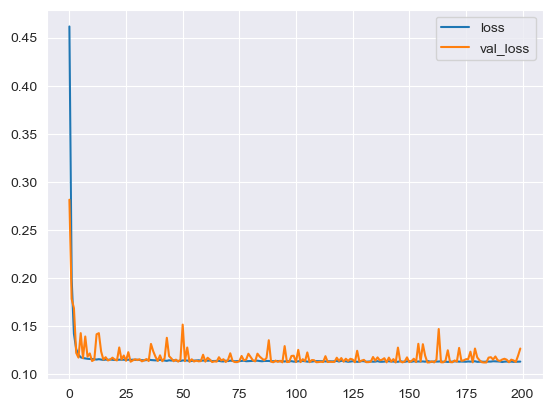

In [232]:
# Creating a DataFrame of model history
best_model_history = pd.DataFrame(best_model.history_)

# Plotting the loss and val_loss
plt.plot(best_model_history['loss'], label='loss')
plt.plot(best_model_history['val_loss'], label='val_loss')
plt.legend() 
plt.show()

In [234]:
# Predicting off of the test dataw
y_pred = (best_model.predict(X_test) > 0.5).astype("int32") 
# Predicting probabilities to be used in roc_auc_score
y_pred_proba = best_model.predict(X_test)

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [236]:
# Printing the confusion matrix
print('For the Tuned ANN:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For the Tuned ANN:

[[26663   812]
 [  686  1839]]


              precision    recall  f1-score   support

           0       0.97      0.97      0.97     27475
           1       0.69      0.73      0.71      2525

    accuracy                           0.95     30000
   macro avg       0.83      0.85      0.84     30000
weighted avg       0.95      0.95      0.95     30000



In [238]:
# Printing the roc_auc_score
print(f'For the Tuned ANN Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For the Tuned ANN Model:
ROC_AUC_Score: 0.85


Well the tuned ANN model had a worse performance than our original ANN model which is a bit surprising. However one thing
to note is that compared to all the previous models so far this tuned ANN model had the best recall for the positive class which 
is a recall of 73%. The second best recall for the positive class was obtained by the tuned XGBoost and was 68%.\
However in achieving this high recall there was a trade off and there was lower precision for the positive class.\
Finally to conclude this project let's create a final ANN model with the best parameters from the random search model and
see whether we will get better results than the tuned ANN model

In [246]:
# Creating a final ANN model called my_best_model
my_best_model = create_model(learning_rate=0.001, activation='relu')

In [249]:
# Fitting my_best_model and assigning history to my_h_callbacks
my_h_callbacks = my_best_model.fit(X_train, y_train, epochs=200, 
                                   validation_data=(X_test,y_test), batch_size=256,
                                   callbacks=[earlystopping])

Epoch 1/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6188 - loss: 0.7910 - val_accuracy: 0.6215 - val_loss: 0.6276
Epoch 2/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9405 - loss: 0.2463 - val_accuracy: 0.9434 - val_loss: 0.2175
Epoch 3/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9437 - loss: 0.1828 - val_accuracy: 0.9266 - val_loss: 0.1848
Epoch 4/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9501 - loss: 0.1486 - val_accuracy: 0.9161 - val_loss: 0.2985
Epoch 5/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9562 - loss: 0.1277 - val_accuracy: 0.9519 - val_loss: 0.1279
Epoch 6/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9574 - loss: 0.1218 - val_accuracy: 0.9573 - val_loss: 0.1216
Epoch 7/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9595 - loss: 0.1156 - val_accuracy: 0.9547 - val_loss: 0.1257
Epoch 8/200
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9585 - loss: 0.1191 - val_ac

In [251]:
# Finding the accuracy of the model
accuracy = my_best_model.evaluate(X_test, y_test)[1]
print(f'Accuracy: {(accuracy*100):.2f}%')

938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9595 - loss: 0.1153
Accuracy: 96.04%


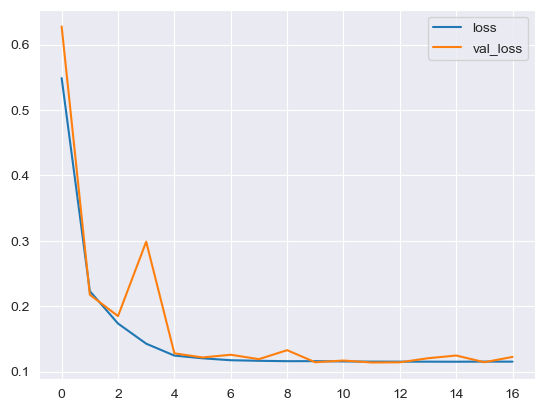

In [257]:
# Creating a DataFrame of model history
my_best_model_history = pd.DataFrame(my_h_callbacks.history)

# Plotting loss and val_loss
plt.plot(my_best_model_history['loss'], label='loss')
plt.plot(my_best_model_history['val_loss'], label='val_loss')
plt.legend() 
plt.show()

In [259]:
# Predicting off of the test dataw
y_pred = (my_best_model.predict(X_test) > 0.5).astype("int32") 
# Predicting probabilities to be used in roc_auc_score
y_pred_proba = my_best_model.predict(X_test)

938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [261]:
# Printing the confusion matrix
print('For My Best ANN:\n')
print(confusion_matrix(y_test, y_pred))
print('\n')
# Printing the classification report
print(classification_report(y_test, y_pred))

For My Best ANN:

[[27200   275]
 [  914  1611]]


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27475
           1       0.85      0.64      0.73      2525

    accuracy                           0.96     30000
   macro avg       0.91      0.81      0.85     30000
weighted avg       0.96      0.96      0.96     30000



In [273]:
# Printing the roc_auc_score
print(f'For My Best ANN Model:\nROC_AUC_Score: {roc_auc_score(y_test, y_pred_proba):.2f}')

For My Best ANN Model:
ROC_AUC_Score: 0.96


### Saving the Best Models

After training our models we can now save them for future use.\
We will start by saving our deep learning model

In [275]:
# Saving my_best_model for future use 
my_best_model.save('deep_learning_models/diabetes_clf_ann_recall0.81_v1.keras')

In [279]:
# Importing keras
import keras

In [281]:
# Loading the saved model
reconstructed_model = keras.models.load_model("deep_learning_models/diabetes_clf_ann_recall0.81_v1.keras")

# Checking whether it's the same as the original
np.testing.assert_allclose(
    my_best_model.predict(X_test), reconstructed_model.predict(X_test)
)

938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


We have successfully trained and saved our deep learning model for future use.\
We can now also save our other best models, that is our Voting Classifier model and our tuned XGBoost model

In [286]:
# Importing dump and load from joblib
from joblib import dump, load 

# Extracting fitted VotingClassifier from the pipeline
voting_clf = pipeline_vc.named_steps['votingclassifier']

# Saving VotingClassifier
dump(voting_clf, 'machine_learning_models/diabetes_clf_voting_recall0.83_v1.joblib')

['machine_learning_models/diabetes_clf_voting_recall0.83_v1.joblib']

In [288]:
# Extracting both XGBoostClassifier and StandardScaler from the pipeline 
std_scaler = best_pipeline_xgb.named_steps['standardscaler']
xgb_clf = best_pipeline_xgb.named_steps['xgbclassifier']

# Saving StandardScaler
dump(std_scaler, 'machine_learning_models/std_scaler.joblib')
# Saving XGBoostClassifier 
dump(xgb_clf, 'machine_learning_models/diabetes_clf_xgb_recall0.84_v1.joblib')

['machine_learning_models/diabetes_clf_xgb_recall0.84_v1.joblib']

### Final Thoughts

After a thorough and iterative process of preprocessing, training, predicting and evaluating we have obtained three models 
that gave the best performance namely, the Voting Classifier model, XGBoostClassifier model and finally our Artificial Neural 
Networks model. We have also saved the three models for future use.\
The models trained in this project may be used on new diabetes data, or even a different diagnosis data set.\
It has been an interesting project with interesting developments where things didn't go as planned.\
All in all, it just goes to show how the field of Data Science and Machine Learning is both daunting and exciting.\
With that we can conclude this project knowing that we got three good models that will be useful in the future